# The linecap attribute when set was not working in Raster

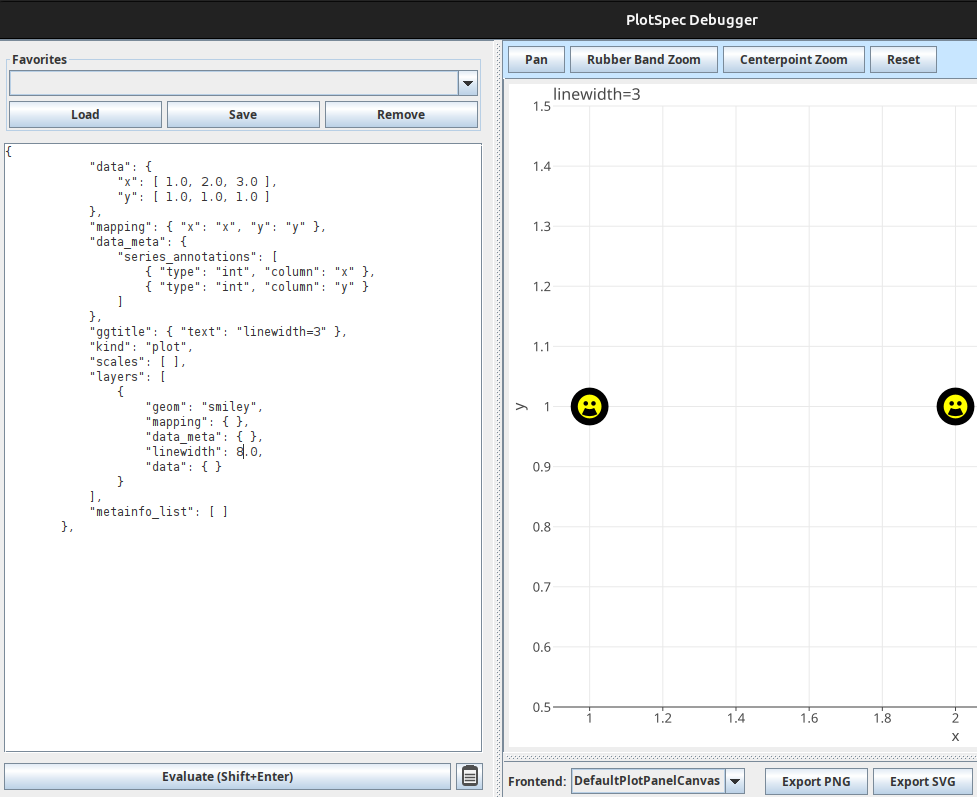

# Now it works correct

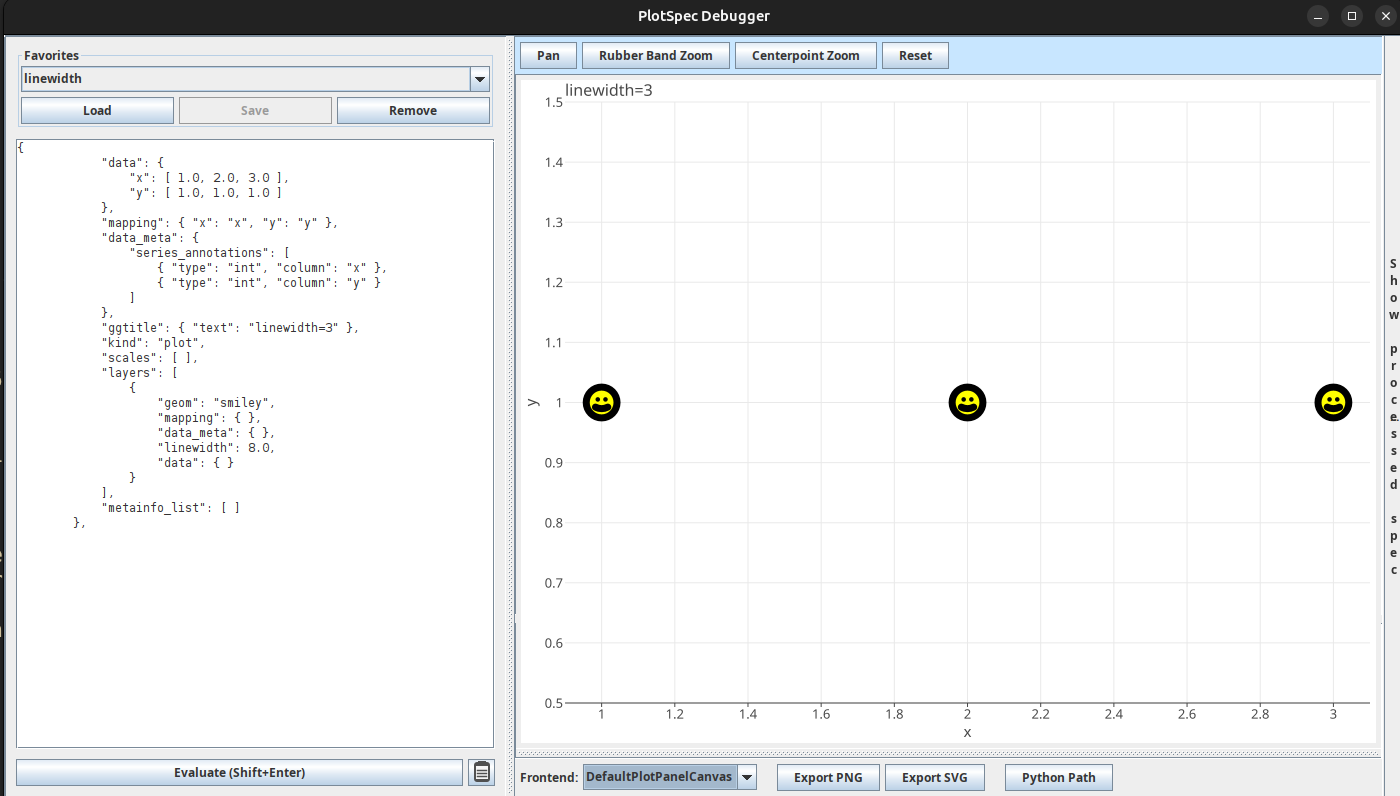


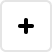
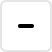
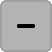
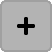
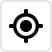
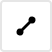
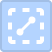
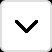
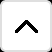
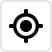
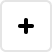
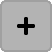
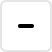
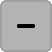
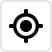
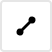
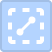
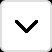
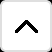
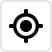

In [1]:
from pyexpat import features

from lets_plot import *
LetsPlot.setup_html(offline=True)

# Simplified `sizeUnitRatio` and `effectiveHappiness` check

## What changed

In  `buildIntern` from
```kotlin
 val sizeScale = if (sizeUnit.isNullOrBlank()) {
                ctx.getScaleFactor()
            } else {
                AesScaling.sizeUnitRatio(location, coord, sizeUnit, AesScaling.POINT_UNIT_SIZE)
            }
```
to:

```kotlin
val sizeScale = AesScaling.sizeUnitRatio(location, coord, sizeUnit, AesScaling.POINT_UNIT_SIZE)
```

The are overwriting each other in any case so the check is not required, only zoom is broken but its okay according to documentation.


In `effectiveHappiness` method was simplified from:

```kotlin
// Before - checks for null AND NaN/Infinity
return (point.finiteOrNull(Aes.HAPPINESS) ?: happiness).coerceIn(-1.0, 1.0)
```

to:

```kotlin
// After - checks for null only
return (point.happiness() ?: happiness).coerceIn(-1.0, 1.0)
```

Python `None` in data stays as Kotlin `null` all the way through the pipeline:
1. Python `None` - stored as `null` in DataFrame (`List<Double?>`)
2. The HAPPINESS aesthetic uses the `IDENTITY` scale mapper, which preserves `null` as-is
3. `point.happiness()` calls `get(Aes.HAPPINESS)` - returns `null`
4. The `?: happiness` fallback triggers - uses geom default (0.5)

In [5]:
data_with_none = {
    "x": [1, 2, 3, 4, 5],
    "y": [1, 1, 1, 1, 1],
    "h": [-1.0, -0.4, None, 0.5, 1.0] 
}

data_clean = {
    "x": [1, 2, 3, 4, 5],
    "y": [1, 1, 1, 1, 1],
    "h": [-1.0, -0.4, 0.0, 0.5, 1.0]
}

p_none = ggplot(data_with_none, aes("x", "y", happiness="h")) + \
    geom_smiley(size=20, fill='yellow', color='black') + \
    ggtitle("None at x=3: falls back to default 0.5 smile")

p_clean = ggplot(data_clean, aes("x", "y", happiness="h")) + \
    geom_smiley(size=20, fill='yellow', color='black') + \
    ggtitle("Clean data: h=0.0 at x=3 gives flat mouth")

gggrid([p_none, p_clean], ncol=1)

# Livemap support

In [3]:
cities = {
    "city": ["Moscow", "London", "Tokyo", "New York", "Sydney"],
    "lon": [37.62, -0.12, 139.69, -74.01, 151.21],
    "lat": [55.75, 51.51, 35.69, 40.71, -33.87],
    "h": [0.8, 0.3, 1.0, -0.5, 0.6]
}

ggplot(cities, aes("lon", "lat", happiness="h")) + \
    geom_livemap(location=[20, 20], zoom=1) + \
    geom_smiley(size=5) + \
    ggtitle("geom_smiley on livemap")